In [ ]:

import pandas as pd
master_file = pd.read_csv("WHO-UCN-TB-2023.6-eng_catalogue_master_file.txt", sep="\t")
# for c in master_file.columns:
#     print(c)

master_file_clean = master_file.dropna(subset=["FINAL CONFIDENCE GRADING"])

master_file_clean["gene"] = master_file_clean["gene"].str.strip()
master_file_clean["mutation"] = master_file_clean["mutation"].str.strip()
master_file_clean["FINAL CONFIDENCE GRADING"] = master_file_clean["FINAL CONFIDENCE GRADING"].str.strip()

# print(master_file_clean["FINAL CONFIDENCE GRADING"].unique())

# ordinally encode resistance grades
grading_scheme = {
    "5) Not assoc w R": 0,
    "4) Not assoc w R - Interim'": 1,
    "3) Uncertain significance": 2,
    "2) Assoc w R - Interim": 3,
    "1) Assoc w R": 4
}

master_file_clean["grade_ordinal"] = master_file_clean["FINAL CONFIDENCE GRADING"].map(grading_scheme)
master_file_clean = master_file_clean.dropna(subset=["grade_ordinal"])

# remove duplicates
# master_file_clean = master_file_clean.drop_duplicates(subset=["mutation", "drug"])

# keep only necessary columns
model_df = master_file_clean[[
    "gene",
    "mutation",
    "drug",
    "grade_ordinal",
    # "PPV_SOLO_DATASET ALL"
]].copy()

one_hot_df = model_df.copy()

# --- Apply to dataframe ---
features_df = one_hot_df['mutation'].apply(extract_features).apply(pd.Series)
one_hot_df = pd.concat([one_hot_df, features_df], axis=1)

# # --- Check how many fell through to unknown ---
# print(one_hot_df['mut_type'].value_counts())
# unknown_mask = one_hot_df['mut_type'] == 'unknown'
# print(f"\n{unknown_mask.sum()} unparsed mutations:")
# for m in one_hot_df.loc[unknown_mask, 'mutation'].unique()[:200]:
#     print(m)

# --- One-hot encode mut_type, ref, alt ---
one_hot_df = pd.get_dummies(one_hot_df, columns=['gene', 'mut_type', 'ref', 'alt'])

# Adding drug embedding columns
embedding_columns_list = [f'drug_embedding_{i}' for i in range(len(drug_embeddings['Amikacin']))]
one_hot_df[embedding_columns_list] = one_hot_df['drug'].map(drug_embeddings).tolist()

# hold out Amikacin and Kanamycin for testing
holdout_drugs = ['Amikacin', 'Kanamycin']
test_df = one_hot_df[one_hot_df['drug'].isin(holdout_drugs)].copy()
train_df = one_hot_df[~one_hot_df['drug'].isin(holdout_drugs)].copy()

one_hot_df = one_hot_df.drop(columns=['drug', 'mutation'])
test_df = test_df.drop(columns=['drug', 'mutation'])
train_df = train_df.drop(columns=['drug', 'mutation'])

print(f"num features: {len(one_hot_df.columns)}")
for c in one_hot_df.columns:
    print(c)
# print(one_hot_df.columns)

/var/folders/_h/ppym6hs50lx51lmb80t8l84m0000gq/T/ipykernel_9374/3989178811.py:180: DtypeWarning: Columns (36,37,99,100,102,103,106,108,112) have mixed types. Specify dtype option on import or set low_memory=False.
  master_file = pd.read_csv("WHO-UCN-TB-2023.6-eng_catalogue_master_file.txt", sep="\t")
/var/folders/_h/ppym6hs50lx51lmb80t8l84m0000gq/T/ipykernel_9374/3989178811.py:234: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  one_hot_df[embedding_columns_list] = one_hot_df['drug'].map(drug_embeddings).tolist()
/var/folders/_h/ppym6hs50lx51lmb80t8l84m0000gq/T/ipykernel_9374/3989178811.py:234: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining al

num features: 506
grade_ordinal
position
del_len
ins_len
gene_PPE35
gene_Rv0010c
gene_Rv0565c
gene_Rv0678
gene_Rv1129c
gene_Rv1258c
gene_Rv1979c
gene_Rv2477c
gene_Rv2680
gene_Rv2681
gene_Rv2752c
gene_Rv2983
gene_Rv3083
gene_Rv3236c
gene_aftB
gene_ahpC
gene_atpE
gene_bacA
gene_ccsA
gene_clpC1
gene_ddn
gene_dnaA
gene_eis
gene_embA
gene_embB
gene_embC
gene_embR
gene_ethA
gene_ethR
gene_fbiA
gene_fbiB
gene_fbiC
gene_fgd1
gene_gid
gene_glpK
gene_gyrA
gene_gyrB
gene_hadA
gene_inhA
gene_katG
gene_lpqB
gene_mmpL5
gene_mmpS5
gene_mshA
gene_mtrA
gene_mtrB
gene_ndh
gene_nusG
gene_panD
gene_pepQ
gene_pncA
gene_rplC
gene_rpoA
gene_rpoB
gene_rpoC
gene_rpsA
gene_rpsL
gene_rrl
gene_rrs
gene_sigE
gene_tlyA
gene_tsnR
gene_ubiA
gene_whiB6
gene_whiB7
mut_type_LoF
mut_type_SNV
mut_type_del
mut_type_delins
mut_type_dup
mut_type_extension
mut_type_frameshift
mut_type_ins
mut_type_missense
mut_type_nonsense
mut_type_uncertain
ref_*
ref_A
ref_C
ref_D
ref_E
ref_F
ref_G
ref_H
ref_I
ref_K
ref_L
ref_M
ref_N
ref_P


In [13]:
# remove rows with NaNs 
train_df = train_df.dropna()
test_df = test_df.dropna()

In [14]:
# Perform PCA for dimensionality reduction with the train_df only to avoid data leakage
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# Standardize features before PCA
scaler = StandardScaler()
train_features_scaled = scaler.fit_transform(train_df.drop(columns=['grade_ordinal']))
test_features_scaled = scaler.transform(test_df.drop(columns=['grade_ordinal']))


# # Apply PCA
# pca = PCA(n_components=0.95, random_state=42)  # keep 95% variance
# train_pca = pca.fit_transform(train_features_scaled)
# test_pca = pca.transform(test_features_scaled)

# # graph explained variance ratio not cumulative
# import matplotlib.pyplot as plt

# import numpy as np
# cumulative_variance = np.cumsum(pca.explained_variance_ratio_)

# n_components = pca.n_components_



# plt.figure(figsize=(10, 6))
# plt.plot(cumulative_variance, marker='o')
# plt.axhline(y=0.95, color='r', linestyle='--', label='95% variance')
# plt.axvline(x=n_components, color='g', linestyle='--', label=f'{n_components} components')
# plt.xlabel('Number of Components')
# plt.ylabel('Cumulative Explained Variance')
# plt.title('Cumulative Explained Variance')
# plt.legend()
# plt.grid()
# plt.show()

The curve rises steeply at first, indicating that the first several principal components capture most of the important information in the data, reaching roughly 70–75% explained variance within about the first 7–8 components. After around 10–15 components, the curve begins to level off, meaning additional components contribute progressively smaller amounts of new variance. This flattening, often called the “elbow,” suggests that keeping roughly 15–20 components provides a good trade-off between dimensionality reduction and information preservation, since adding more components yields only marginal improvement.

In [15]:
# # create a UMAP of the training set only to avoid data leakage, and color by grade_ordinal
# import umap
# reducer = umap.UMAP(n_neighbors=10, min_dist=0.05, metric='cosine', random_state=42)
# train_umap = reducer.fit_transform(train_pca)

# plt.figure(figsize=(10, 6))
# plt.scatter(train_umap[:, 0], train_umap[:, 1], c=train_df['grade_ordinal'], cmap='viridis', label='Train', alpha=0.7)
# plt.xlabel('UMAP Dimension 1')
# plt.ylabel('UMAP Dimension 2')
# plt.title('UMAP Projection of Train Set Colored by Grade Ordinal')
# plt.legend()
# plt.grid()
# plt.show()

[9.97480826e-01 2.14269276e-03 1.62202983e-04 7.07750287e-05
 5.48188090e-05 3.46741576e-05 1.30125190e-05 8.00787337e-06
 6.04180371e-06 3.95973013e-06 3.03831875e-06 2.36508355e-06
 2.19078805e-06 1.64315053e-06 1.09664785e-06 9.26840100e-07
 7.01895821e-07 6.83632354e-07 5.51400170e-07 5.31353535e-07
 4.88289597e-07 4.63373409e-07 3.84320347e-07 3.50369073e-07
 3.25164717e-07 2.75073321e-07 2.63838319e-07 2.54008132e-07
 2.42541673e-07 2.39904311e-07 2.12234228e-07 2.07969138e-07
 2.01801088e-07 1.94776031e-07 1.86782598e-07 1.74970841e-07
 1.67905048e-07 1.64085952e-07 1.57177151e-07 1.50849951e-07
 1.40602487e-07 1.36123701e-07 1.20468319e-07 1.19375504e-07
 1.14171411e-07 1.08868699e-07 1.07512966e-07 1.02364224e-07
 1.01328845e-07 9.81954955e-08 9.67968259e-08 9.39835689e-08
 9.19303997e-08 8.59019071e-08 8.45417069e-08 8.34368157e-08
 8.20080180e-08 8.04604008e-08 7.82508209e-08 7.47455899e-08
 7.38143990e-08 7.17314545e-08 7.14035832e-08 6.80198569e-08
 6.60750142e-08 6.484028

/opt/miniconda3/envs/msse-3.11/lib/python3.11/site-packages/seaborn/_oldcore.py:1765: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  order = pd.unique(vector)


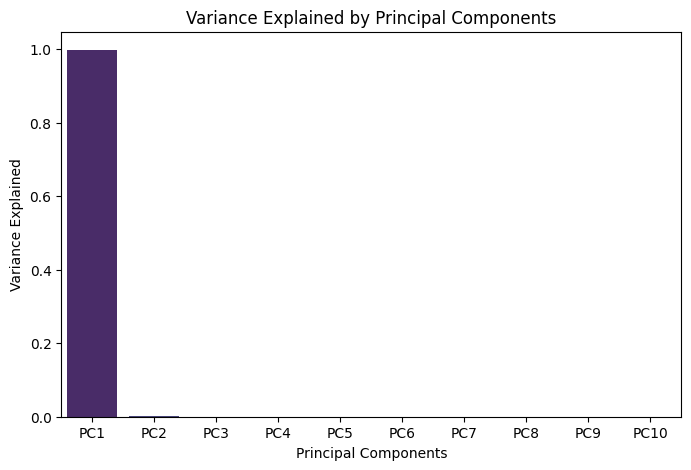

In [16]:
from sklearn.decomposition import PCA
pca = PCA(n_components=300)
baseline_data = one_hot_df.copy().dropna()
principal_components = pca.fit_transform(baseline_data)

# graph the variance explained by the principal components
print(pca.explained_variance_ratio_)
explained_variance = pca.explained_variance_ratio_
plt.figure(figsize=(8, 5))
sns.barplot(x=[f"PC{i+1}" for i in range(10)], y=explained_variance[:10], palette="viridis")
plt.title("Variance Explained by Principal Components")
plt.xlabel("Principal Components")
plt.ylabel("Variance Explained")
plt.show()

              precision    recall  f1-score   support

         0.0       0.06      0.54      0.10        97
         2.0       0.99      0.84      0.91      6781
         3.0       0.64      0.83      0.72       226
         4.0       0.19      0.69      0.30        51

    accuracy                           0.84      7155
   macro avg       0.47      0.72      0.51      7155
weighted avg       0.96      0.84      0.89      7155

Accuracy: 0.84


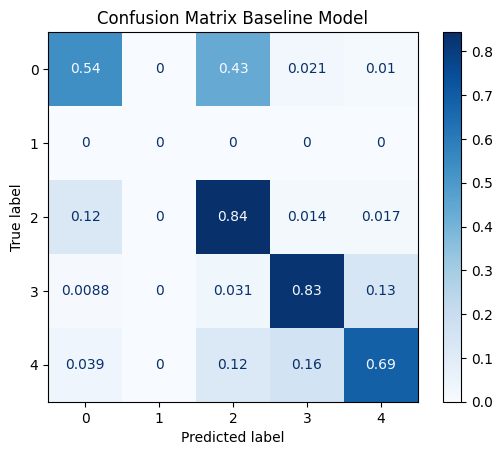

In [17]:

baseline_data = one_hot_df.copy()
x_base = baseline_data.drop(columns=["grade_ordinal"])
y_base = baseline_data["grade_ordinal"]

x_base = x_base.fillna(0) # sometimes the inserts or deletes are not a number

# print(x_base.head())

# split training and test data
Xb_train, Xb_test, yb_train, yb_test = train_test_split(x_base, y_base, test_size=0.2, random_state=42, stratify=y_base)

from sklearn.ensemble import HistGradientBoostingClassifier
clf = HistGradientBoostingClassifier(max_depth=5, random_state=0, class_weight='balanced').fit(Xb_train, yb_train)

# predict resistance class
y_pred = clf.predict(Xb_test)

print(classification_report(yb_test, y_pred))

# Display the accuracy
accuracy = np.mean(yb_test == y_pred)
print(f'Accuracy: {accuracy:.2f}')

# Plot the confusion matrix
labels = [0, 1, 2, 3, 4]
cm = confusion_matrix(yb_test, y_pred, normalize = 'true', labels=labels)
disp = ConfusionMatrixDisplay(confusion_matrix = cm)
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix Baseline Model")
plt.show()


In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import HistGradientBoostingClassifier

param_grid = {
    'max_depth':      [3, 7, None],         # tree depth; None = unlimited
    'min_samples_leaf': [10, 20],          # regularisation via minimum leaf size
    'l2_regularization': [0.0, 0.5, 1.0],     # L2 penalty on leaf values
    'max_leaf_nodes': [15, 60],            # alternative tree complexity control to max_depth
}

clf = HistGradientBoostingClassifier(
    random_state=0,
    class_weight='balanced'
)

from sklearn.experimental import enable_halving_search_cv
from sklearn.model_selection import HalvingGridSearchCV

grid_search = HalvingGridSearchCV(
    clf,
    param_grid,
    factor=3,         # keeps top 1/3 of candidates each round
    cv=5,
    scoring='f1_weighted',
    n_jobs=-1,
    verbose=2
)

grid_search.fit(Xb_train, yb_train)

print("Best params:", grid_search.best_params_)
print("Best CV score:", grid_search.best_score_)

y_pred = grid_search.best_estimator_.predict(Xb_test)
print(classification_report(yb_test, y_pred))

In [ ]:
# from sklearn.svm import SVC
# from sklearn.model_selection import GridSearchCV
# from sklearn.metrics import classification_report

# param_grid = [
#     # RBF kernel — most generally powerful, tune C and gamma
#     {
#         'kernel': ['rbf'],
#         'C':      [0.1, 1, 10, 100],
#         'gamma':  ['scale', 'auto', 0.001, 0.01, 0.1],
#     },
#     # Linear kernel — good for high-dimensional data, only C matters
#     {
#         'kernel': ['linear'],
#         'C':      [0.1, 1, 10, 100],
#     },
#     # Polynomial kernel — captures feature interactions
#     {
#         'kernel': ['poly'],
#         'C':      [0.1, 1, 10],
#         'degree': [2, 3, 4],
#         'gamma':  ['scale', 'auto'],
#         'coef0':  [0.0, 0.5, 1.0],   # shifts the polynomial (affects degree interaction)
#     },
#     # Sigmoid kernel — behaves like a neural net activation
#     {
#         'kernel': ['sigmoid'],
#         'C':      [0.1, 1, 10],
#         'gamma':  ['scale', 'auto'],
#         'coef0':  [0.0, 0.5, 1.0],
#     },
# ]

# svm = SVC(
#     random_state=0,
#     class_weight='balanced',   # keep consistent with your HGBC setup
#     probability=True           # enables predict_proba if you need it later
# )

# from sklearn.model_selection import HalvingGridSearchCV

# grid_search = HalvingGridSearchCV(
#     svm,
#     param_grid,
#     factor=3,         # keeps top 1/3 of candidates each round
#     cv=5,
#     scoring='f1_weighted',
#     n_jobs=-1
# )

# grid_search.fit(Xb_train, yb_train)

# print("Best params: ", grid_search.best_params_)
# print("Best CV score:", grid_search.best_score_)

# y_pred = grid_search.best_estimator_.predict(Xb_test)
# print(classification_report(yb_test, y_pred))